In [7]:
import pandas as pd
import seaborn as sns

# Get the list of dataset names
dataset_names = sns.get_dataset_names()

# Create a pandas DataFrame
dataset_df = pd.DataFrame(dataset_names, columns=['Seaborn Dataset Names'])

# Display the DataFrame
display(dataset_df)

,Seaborn Dataset Names
0,anagrams
1,anscombe
2,attention
3,brain_networks
4,car_crashes
5,diamonds
6,dots
7,dowjones
8,exercise
9,flights


In [11]:
import seaborn as sns

# Load the 'tips' dataset
tips_df = sns.load_dataset('iris')

# Display the first few rows of the dataset
print("First 5 rows of the 'tips' dataset:")
display(tips_df.head())

# Display information about the dataset
print("\n'tips' dataset Info:")
tips_df.info()

First 5 rows of the 'tips' dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



'tips' dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [1]:
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load a dataset
df = sns.load_dataset('iris')

# Display first few rows and info
print("First 5 rows of the dataset:")
display(df.head())
print("\nDataset Info:")
df.info()

# Select numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Handle missing values (if any, iris dataset has no missing values)
numerical_df = numerical_df.dropna()

# Scale the numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numerical_df)
scaled_df = pd.DataFrame(scaled_data, columns=numerical_df.columns)

print("\nScaled Data:")
display(scaled_df.head())

First 5 rows of the dataset:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Scaled Data:


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [2]:
from sklearn.cluster import KMeans

# Instantiate KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init=10 to suppress warning

# Fit the model to the scaled data
kmeans.fit(scaled_df)

# Get the cluster labels
builtin_cluster_labels = kmeans.labels_

# Add cluster labels to the original dataframe
df['builtin_cluster'] = builtin_cluster_labels

# Display the first few rows with the new cluster column
print("Original DataFrame with Built-in KMeans Cluster Labels:")
display(df.head())

Original DataFrame with Built-in KMeans Cluster Labels:


,sepal_length,sepal_width,petal_length,petal_width,species,builtin_cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [3]:
import numpy as np

def euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points."""
    return np.sqrt(np.sum((point1 - point2)**2))

def initialize_centroids(data, k):
    """Initializes k centroids by randomly selecting data points."""
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def assign_clusters(data, centroids):
    """Assigns each data point to the nearest centroid."""
    distances = np.zeros((data.shape[0], centroids.shape[0]))
    for i in range(data.shape[0]):
        for j in range(centroids.shape[0]):
            distances[i, j] = euclidean_distance(data[i], centroids[j])
    return np.argmin(distances, axis=1)

def update_centroids(data, assignments, k):
    """Updates the centroids based on the mean of assigned data points."""
    new_centroids = np.zeros((k, data.shape[1]))
    for i in range(k):
        cluster_points = data[assignments == i]
        if len(cluster_points) > 0:
            new_centroids[i] = np.mean(cluster_points, axis=0)
        else:
            # If a cluster is empty, re-initialize its centroid
            new_centroids[i] = data[np.random.choice(data.shape[0])]
    return new_centroids

def kmeans_from_scratch(data, k, max_iterations=100):
    """Implements K-Means clustering from scratch."""
    centroids = initialize_centroids(data, k)
    for _ in range(max_iterations):
        assignments = assign_clusters(data, centroids)
        new_centroids = update_centroids(data, assignments, k)
        if np.allclose(centroids, new_centroids):
            break  # Convergence
        centroids = new_centroids
    return assignments

# Perform K-Means from scratch on the scaled data
k = 3  # Number of clusters
scratch_cluster_labels = kmeans_from_scratch(scaled_df.values, k)

# Store the final cluster assignments
df['scratch_cluster'] = scratch_cluster_labels

# Display the first few rows with the new cluster column
print("Original DataFrame with K-Means from Scratch Cluster Labels:")
display(df.head())

Original DataFrame with K-Means from Scratch Cluster Labels:


,sepal_length,sepal_width,petal_length,petal_width,species,builtin_cluster,scratch_cluster
0,5.1,3.5,1.4,0.2,setosa,1,0
1,4.9,3.0,1.4,0.2,setosa,1,1
2,4.7,3.2,1.3,0.2,setosa,1,1
3,4.6,3.1,1.5,0.2,setosa,1,1
4,5.0,3.6,1.4,0.2,setosa,1,0


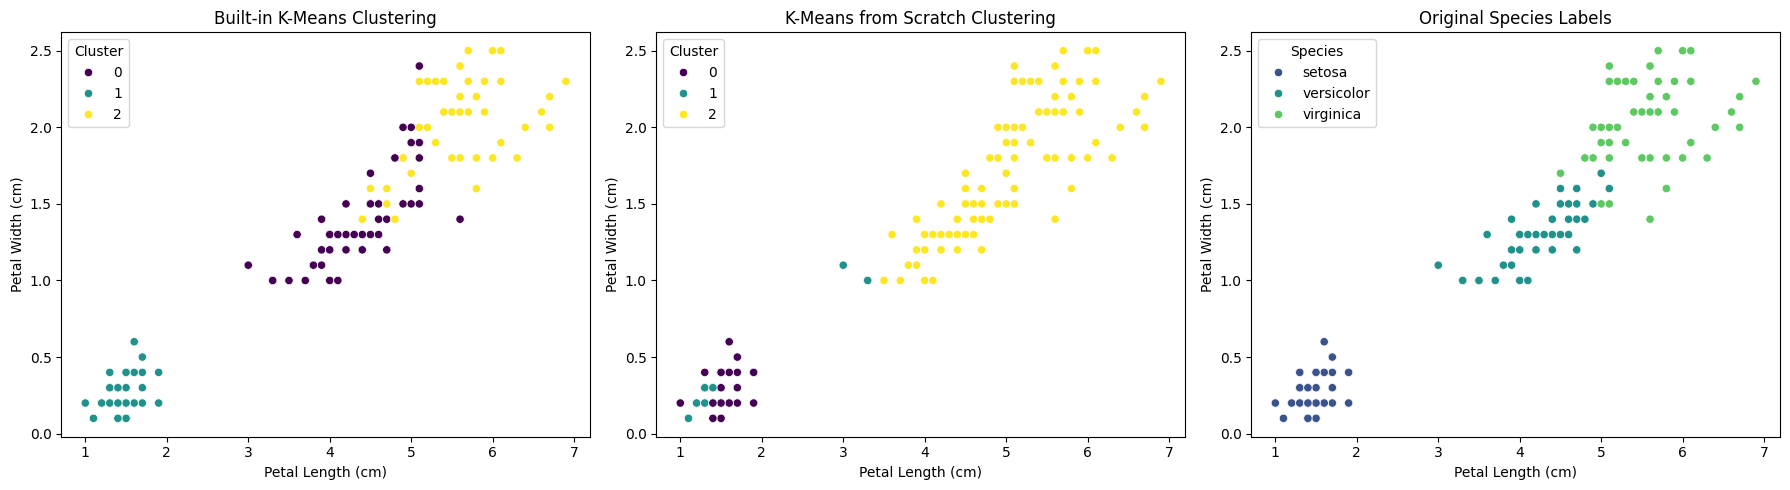

In [4]:
import matplotlib.pyplot as plt

# Set up the figure and axes for the subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Built-in K-Means clusters
sns.scatterplot(x='petal_length', y='petal_width', hue='builtin_cluster', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Built-in K-Means Clustering')
axes[0].set_xlabel('Petal Length (cm)')
axes[0].set_ylabel('Petal Width (cm)')
axes[0].legend(title='Cluster')

# Plot 2: K-Means from scratch clusters
sns.scatterplot(x='petal_length', y='petal_width', hue='scratch_cluster', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('K-Means from Scratch Clustering')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].legend(title='Cluster')

# Plot 3: Original species labels
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df, ax=axes[2], palette='viridis')
axes[2].set_title('Original Species Labels')
axes[2].set_xlabel('Petal Length (cm)')
axes[2].set_ylabel('Petal Width (cm)')
axes[2].legend(title='Species')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()